In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linearmodels.panel import PanelOLS
import statsmodels.formula.api as smf
import os
import requests
from scipy.spatial.distance import mahalanobis
from scipy import stats
from sklearn.preprocessing import StandardScaler

In [2]:
# Set working directory to the project root (one level up from src/)
os.chdir("..")

In [3]:
pd.set_option('display.max_rows', None)

# Load and describe the data
* Load the two time series and merge them into a long format
* Drop regional/income groups 

In [4]:
df_maternal = pd.read_csv('data/API_SH.STA.MMRT_DS2_en_csv_v2_708.csv', skiprows=4)
df_parl = pd.read_csv('data/API_SG.GEN.PARL.ZS_DS2_en_csv_v2_188.csv', skiprows=4)

In [5]:
# convert to long format
id_vars = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"]
year_cols = [c for c in df_maternal.columns if c.isdigit()]

df_maternal = (df_maternal
       .melt(id_vars=id_vars, value_vars=year_cols, var_name="year", value_name="maternal_mortality")
       .assign(year=lambda x: x["year"].astype(int))
       .rename(columns={
           'Country Code': "country_code",
           'Country Name': "country_name"
       })
       .drop(["Indicator Name", "Indicator Code"], axis=1)
       )

df_parl = (df_parl
       .melt(id_vars=id_vars, value_vars=year_cols, var_name="year", value_name="women_parl_pct")
       .assign(year=lambda x: x["year"].astype(int))
       .rename(columns={
           'Country Code': "country_code",
           'Country Name': "country_name"
       })
       .drop(["Indicator Name", "Indicator Code"], axis=1)
       )


In [6]:
# merge on country + year
df = pd.merge(df_maternal, df_parl,
              on=["country_name", "country_code", "year"],
              how="outer")

df = df.sort_values(['country_code', 'year']).reset_index(drop=True)

In [7]:
# remove non-country observations (regions, income groups)
# get country codes from World Bank list of individual countries
response = requests.get("https://api.worldbank.org/v2/country?format=json&per_page=300")
data = response.json()  # returns [metadata, [list of countries]]

country_codes = [
    c["id"] for c in data[1]
    if c["region"]["value"] != "Aggregates"
]

df = df[df['country_code'].isin(country_codes)]

In [8]:
df.head()

,country_name,country_code,year,maternal_mortality,women_parl_pct
0,Aruba,ABW,1960,NaN,NaN
1,Aruba,ABW,1961,NaN,NaN
2,Aruba,ABW,1962,NaN,NaN
3,Aruba,ABW,1963,NaN,NaN
4,Aruba,ABW,1964,NaN,NaN


In [9]:
# ── Coverage by year ───────────────────────────────────────────────────────────
year_coverage = df.groupby("year").agg(
    n_countries=("country_code", "count"),
    missing_maternal=("maternal_mortality", lambda x: x.isnull().sum()),
    missing_parl=("women_parl_pct", lambda x: x.isnull().sum()),
).reset_index()

year_coverage["maternal_coverage_pct"] = (1 - year_coverage["missing_maternal"] / year_coverage["n_countries"]).mul(100).round(1)
year_coverage["parl_coverage_pct"]     = (1 - year_coverage["missing_parl"]     / year_coverage["n_countries"]).mul(100).round(1)

print(year_coverage.to_string(index=False))

 year  n_countries  missing_maternal  missing_parl  maternal_coverage_pct  parl_coverage_pct
 1960          217               217           217                    0.0                0.0
 1961          217               217           217                    0.0                0.0
 1962          217               217           217                    0.0                0.0
 1963          217               217           217                    0.0                0.0
 1964          217               217           217                    0.0                0.0
 1965          217               217           217                    0.0                0.0
 1966          217               217           217                    0.0                0.0
 1967          217               217           217                    0.0                0.0
 1968          217               217           217                    0.0                0.0
 1969          217               217           217                    

In [10]:
# we will limit the time series to 1997 to 2023 given the yearly data coverage
df = df[(df['year'] >= 1997) & (df['year'] <= 2023)]

In [11]:
# ── Summary statistics ─────────────────────────────────────────────────────────
print(f"Countries: {df['country_code'].nunique()}")
print(f"Years:     {df['year'].min()} – {df['year'].max()}")
print(f"Obs:       {len(df):,}")
print(f"\nMissing maternal_mortality: {df['maternal_mortality'].isna().mean():.2%}")
print(f"Missing women_parl_pct: {df['women_parl_pct'].isna().mean():.2%}")
print("\nSummary statistics:")
print(df[["maternal_mortality", "women_parl_pct"]].describe().round(2))

# ── Coverage per country (how many years each country has data) ────────────────
print("\n=== Coverage per Country ===")
coverage = (
    df.groupby("country_name")
    .agg(
        years_available=("year", "count"),
        year_min=("year", "min"),
        year_max=("year", "max"),
        missing_maternal=("maternal_mortality", lambda x: x.isnull().mean()),
        missing_parl=("women_parl_pct", lambda x: x.isnull().mean()),
    )
    .reset_index()
    .sort_values("years_available", ascending=False)
)

print(coverage.to_string(index=False))

# ── Flag countries below minimum panel requirements (N>=49, T>=6) ──────────────
print("\n=== Countries Below Minimum T=6 ===")
print(coverage[coverage["years_available"] < 6]["country_name"].tolist())

Countries: 217
Years:     1997 – 2023
Obs:       5,859

Missing maternal_mortality: 10.60%
Missing women_parl_pct: 16.50%

Summary statistics:
       maternal_mortality  women_parl_pct
count             5238.00         4892.00
mean               184.37           18.06
std                291.59           11.86
min                  1.00            0.00
25%                 15.00            9.09
50%                 60.00           16.23
75%                237.75           25.41
max               7514.00           63.75

=== Coverage per Country ===
                  country_name  years_available  year_min  year_max  missing_maternal  missing_parl
                   Afghanistan               27      1997      2023               0.0      0.407407
                       Albania               27      1997      2023               0.0      0.074074
                       Algeria               27      1997      2023               0.0      0.000000
                American Samoa               27  

In [12]:
# drop countries with less than 6 observations and countries with less than 50% coverage
to_drop = coverage[
    (coverage["years_available"] < 6) |
    (coverage["missing_maternal"] > 0.5) |
    (coverage["missing_parl"] > 0.5)
]["country_name"].tolist()

print(f"Countries dropped: {len(to_drop)}")
print(to_drop)

df = df[~df["country_name"].isin(to_drop)].reset_index(drop=True)
print(f"\nFinal panel shape: {df.shape}")
print(f"Countries remaining: {df['country_name'].nunique()}")

Countries dropped: 28
['American Samoa', 'Aruba', 'Bermuda', 'British Virgin Islands', 'Brunei Darussalam', 'Cayman Islands', 'Channel Islands', 'Curacao', 'Faroe Islands', 'French Polynesia', 'Gibraltar', 'Greenland', 'Guam', 'Hong Kong SAR, China', 'Isle of Man', 'Kosovo', 'Liechtenstein', 'Macao SAR, China', 'Myanmar', 'New Caledonia', 'Northern Mariana Islands', 'Puerto Rico (US)', 'Sint Maarten (Dutch part)', 'South Sudan', 'St. Martin (French part)', 'Turks and Caicos Islands', 'Virgin Islands (U.S.)', 'West Bank and Gaza']

Final panel shape: (5103, 5)
Countries remaining: 189


In [13]:
# convert maternal mortality (per 100000 live births) to percentage rate
df['maternal_mortality_pct'] = df['maternal_mortality'] / 100000 * 100

df.drop('maternal_mortality', axis=1, inplace=True)

In [14]:
# ── Summary statistics ─────────────────────────────────────────────────────────
print(f"Countries: {df['country_code'].nunique()}")
print(f"Years:     {df['year'].min()} – {df['year'].max()}, ({df['year'].max() - df['year'].min()} years)")
print(f"Obs:       {len(df):,}")

print(f"\nMissing maternal_mortality_pct: {df['maternal_mortality_pct'].isna().mean():.2%}")
print(f"Missing women_parl_pct: {df['women_parl_pct'].isna().mean():.2%}")

print("\nSummary statistics:")
print(df[["maternal_mortality_pct", "women_parl_pct"]].describe().round(2))

Countries: 189
Years:     1997 – 2023, (26 years)
Obs:       5,103

Missing maternal_mortality_pct: 0.00%
Missing women_parl_pct: 5.31%

Summary statistics:
       maternal_mortality_pct  women_parl_pct
count                 5103.00         4832.00
mean                     0.18           18.07
std                      0.26           11.89
min                      0.00            0.00
25%                      0.01            9.09
50%                      0.06           16.24
75%                      0.24           25.40
max                      1.75           63.75


## Add confounder variables

In [15]:
LAST_RECENT_YEAR = df['year'].max()

In [16]:
df_gdp = pd.read_csv('./data/API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_35.csv', skiprows=4)    # gdp per capita
df_fert = pd.read_csv('./data/API_SP.DYN.TFRT.IN_DS2_en_csv_v2_140.csv', skiprows=4)     # fertility rate
df_lab = pd.read_csv('./data/API_SL.TLF.TOTL.FE.ZS_DS2_en_csv_v2_9726.csv', skiprows=4)  # women labor force participation rate
df_idx = pd.read_csv('./data/API_SG.LAW.INDX_DS2_en_csv_v2_6281.csv', skiprows=4)        # business law index

def convert_to_long_fmt(df, value_name):
    id_vars = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"]
    year_cols = [c for c in df.columns if c.isdigit() and int(c) <= LAST_RECENT_YEAR]
    df = (df
        .melt(id_vars=id_vars, value_vars=year_cols, var_name="year", value_name=value_name)
        .assign(year=lambda x: x["year"].astype(int))
        .rename(columns={
           'Country Code': "country_code",
       })
       .drop(columns=["Indicator Name", "Indicator Code", "Country Name"])
    )
    return df


df_gdp = convert_to_long_fmt(df_gdp, 'gdp_pc')
df_fert = convert_to_long_fmt(df_fert, 'fertility')
df_idx = convert_to_long_fmt(df_idx, 'business_law_idx')
df_lab = convert_to_long_fmt(df_lab, 'women_labor_pct')

In [17]:
df = pd.merge(df, df_gdp, on=['country_code', 'year'], how='left')
df = pd.merge(df, df_fert, on=['country_code', 'year'], how='left')
df = pd.merge(df, df_idx, on=['country_code', 'year'], how='left')
df = pd.merge(df, df_lab, on=['country_code', 'year'], how='left')

In [18]:
df.head()

,country_name,country_code,year,women_parl_pct,maternal_mortality_pct,gdp_pc,fertility,business_law_idx,women_labor_pct
0,Afghanistan,AFG,1997,NaN,1.376,NaN,7.732,25.625,16.163462
1,Afghanistan,AFG,1998,NaN,1.464,NaN,7.693,25.625,15.962673
2,Afghanistan,AFG,1999,NaN,1.346,NaN,7.641,26.250,15.771879
3,Afghanistan,AFG,2000,NaN,1.372,813.550256,7.566,26.250,15.609885
4,Afghanistan,AFG,2001,NaN,1.311,747.688045,7.453,26.250,15.499749


In [19]:
# convert to log scale for gdp per capita and fertility rate
df['ln_gdp_pc'] = np.log(df['gdp_pc'])
df['ln_fertility'] = np.log(df['fertility'])
df.drop(['gdp_pc', 'fertility'], axis=1, inplace=True)

In [20]:
# ── Summary statistics ─────────────────────────────────────────────────────────
print(f"Countries: {df['country_code'].nunique()}")
print(f"Years:     {df['year'].min()} – {df['year'].max()}, ({df['year'].max() - df['year'].min()} years)")
print(f"Obs:       {len(df):,}")

print(f"\nMissing maternal_mortality_pct: {df['maternal_mortality_pct'].isna().mean():.2%}")
print(f"Missing women_parl_pct: {df['women_parl_pct'].isna().mean():.2%}")
print(f"Missing ln_gdp_pc: {df['ln_gdp_pc'].isna().mean():.2%}")
print(f"Missing ln_fertility: {df['ln_fertility'].isna().mean():.2%}")
print(f"Missing business_law_idx: {df['business_law_idx'].isna().mean():.2%}")
print(f"Missing women_labor_pct: {df['women_labor_pct'].isna().mean():.2%}")

print("\nSummary statistics:")
print(df[["maternal_mortality_pct", "women_parl_pct", "ln_gdp_pc", "ln_fertility", "business_law_idx", "women_labor_pct"]].describe().round(2))

Countries: 189
Years:     1997 – 2023, (26 years)
Obs:       5,103

Missing maternal_mortality_pct: 0.00%
Missing women_parl_pct: 5.31%
Missing ln_gdp_pc: 3.04%
Missing ln_fertility: 0.00%
Missing business_law_idx: 3.70%
Missing women_labor_pct: 7.47%

Summary statistics:
       maternal_mortality_pct  women_parl_pct  ln_gdp_pc  ln_fertility  \
count                 5103.00         4832.00    4948.00       5103.00   
mean                     0.18           18.07       9.10          0.95   
std                      0.26           11.89       1.22          0.50   
min                      0.00            0.00       5.96         -0.33   
25%                      0.01            9.09       8.12          0.53   
50%                      0.06           16.24       9.18          0.89   
75%                      0.24           25.40      10.07          1.38   
max                      1.75           63.75      12.11          2.06   

       business_law_idx  women_labor_pct  
count           4

# Event study: Whether crossing 30% women representation in parliament affect maternal mortality rate

## Checking which countries achieved 30% women representation in parliament and when

In [21]:
# ── Create critical mass binary ────────────────────────────────────────────────
THRESHOLD = 30
df["critical_mass"] = (df["women_parl_pct"] >= THRESHOLD).astype(int)

# ── Summary of treatment ───────────────────────────────────────────────────────
n_ever_treated = df.groupby("country_code")["critical_mass"].max().sum()
print(f"Countries that ever crossed {THRESHOLD}% threshold: {n_ever_treated}")
print(f"Countries that never crossed {THRESHOLD}% threshold: {df['country_code'].nunique() - n_ever_treated}")

Countries that ever crossed 30% threshold: 71
Countries that never crossed 30% threshold: 118


In [22]:
# ever_treated flag per country
ever_treated = (
    df.groupby("country_code")["critical_mass"]
    .max()
    .reset_index()
    .rename(columns={"critical_mass": "treated"})
)
 
# first crossing year per treated country
first_cross_code = (
    df[df["critical_mass"] == 1]
    .groupby("country_code")["year"]
    .min()
    .reset_index()
    .rename(columns={"year": "first_cross_year"})
)
 
# merge into single metadata table
df_meta = ever_treated.merge(first_cross_code, on="country_code", how="left")
 
# never-treated countries get first_cross_year = sample end + 1 (i.e. never treated)
df_meta["first_cross_year"] = df_meta["first_cross_year"].fillna(df["year"].max() + 1)
 
print(df_meta.head(10))
print(f"\nTreated countries:       {df_meta['treated'].sum()}")
print(f"Never-treated countries: {(df_meta['treated'] == 0).sum()}")

  country_code  treated  first_cross_year
0          AFG        0            2024.0
1          AGO        1            2008.0
2          ALB        1            2021.0
3          AND        1            2009.0
4          ARE        1            2019.0
5          ARG        1            2002.0
6          ARM        1            2021.0
7          ATG        0            2024.0
8          AUS        1            2019.0
9          AUT        1            2003.0

Treated countries:       71
Never-treated countries: 118


## Filter treatment countries with sufficient observations before and after the event

In [23]:
MIN_PRE      = 3
MIN_POST     = 3
SAMPLE_START = df["year"].min()   # 1997
SAMPLE_END   = df["year"].max()   # 2023
 
def check_treatment_window(row):
    """Check if a treated country has enough pre and post treatment years."""
    first_cross_year = row["first_cross_year"]
    pre_years  = first_cross_year - SAMPLE_START
    post_years = SAMPLE_END - first_cross_year + 1
    return pd.Series({
        "pre_years":  pre_years,
        "post_years": post_years,
        "sufficient": (pre_years >= MIN_PRE) and (post_years >= MIN_POST)
    })
 
# apply only to treated countries
treated_meta = df_meta[df_meta["treated"] == 1].copy()
window_check = treated_meta.apply(check_treatment_window, axis=1)
treated_meta = pd.concat([treated_meta, window_check], axis=1)
 
country_names = df[["country_code", "country_name"]].drop_duplicates()
 
print(f"Treated countries before filtering: {len(treated_meta)}")
print(f"Treated countries with sufficient window: {treated_meta['sufficient'].sum()}")
print(f"Treated countries dropped: {(~treated_meta['sufficient']).sum()}")
 
print("\nDropped treated countries (insufficient window):")
print(
    treated_meta[~treated_meta["sufficient"]]
    .merge(country_names, on="country_code")
    [["country_name", "first_cross_year", "pre_years", "post_years"]]
    .to_string(index=False)
)
 
print("\nRetained treated countries:")
print(
    treated_meta[treated_meta["sufficient"]]
    .merge(country_names, on="country_code")
    [["country_name", "first_cross_year", "pre_years", "post_years"]]
    .to_string(index=False)
)
 
eligible_treated   = treated_meta[treated_meta["sufficient"]]["country_code"].tolist()
never_treated_list = df_meta[df_meta["treated"] == 0]["country_code"].tolist()
eligible_countries = eligible_treated + never_treated_list
 
df_eligible = df[df["country_code"].isin(eligible_countries)].copy()
 
print(f"\nEligible treated countries:  {len(eligible_treated)}")
print(f"Never-treated countries:     {len(never_treated_list)}")
print(f"Total countries in sample:   {df_eligible['country_code'].nunique()}")
print(f"Panel shape:                 {df_eligible.shape}")

Treated countries before filtering: 71
Treated countries with sufficient window: 61
Treated countries dropped: 10

Dropped treated countries (insufficient window):
       country_name  first_cross_year  pre_years  post_years
            Germany            1999.0        2.0        25.0
            Denmark            1997.0        0.0        27.0
            Finland            1997.0        0.0        27.0
  Equatorial Guinea            2022.0       25.0         2.0
            Iceland            1999.0        2.0        25.0
St. Kitts and Nevis            2022.0       25.0         2.0
        Netherlands            1997.0        0.0        27.0
             Norway            1997.0        0.0        27.0
             Sweden            1997.0        0.0        27.0
       South Africa            1999.0        2.0        25.0

Retained treated countries:
        country_name  first_cross_year  pre_years  post_years
              Angola            2008.0       11.0        16.0
            

In [24]:
df_eligible.head()

,country_name,country_code,year,women_parl_pct,maternal_mortality_pct,business_law_idx,women_labor_pct,ln_gdp_pc,ln_fertility,critical_mass
0,Afghanistan,AFG,1997,NaN,1.376,25.625,16.163462,NaN,2.045368,0
1,Afghanistan,AFG,1998,NaN,1.464,25.625,15.962673,NaN,2.040311,0
2,Afghanistan,AFG,1999,NaN,1.346,26.250,15.771879,NaN,2.033528,0
3,Afghanistan,AFG,2000,NaN,1.372,26.250,15.609885,6.701408,2.023665,0
4,Afghanistan,AFG,2001,NaN,1.311,26.250,15.499749,6.616986,2.008617,0


In [25]:
df_meta.head()

,country_code,treated,first_cross_year
0,AFG,0,2024.0
1,AGO,1,2008.0
2,ALB,1,2021.0
3,AND,1,2009.0
4,ARE,1,2019.0


## Propensity score matching to select synthetic control group

In [26]:
# merge first_cross_year and treated into df_eligible
df_eligible = df_eligible.merge(df_meta, on="country_code", how="left")
 
# flag pre-treatment rows per country
df_eligible["pre_treatment"] = df_eligible["year"] < df_eligible["first_cross_year"]
 
# features used for matching
FEATURES = ["maternal_mortality_pct", "ln_gdp_pc", "ln_fertility", "business_law_idx", "women_labor_pct"]
 
def compute_features(group):
    """Compute pre-treatment summary features for matching."""
    pre = group[group["pre_treatment"]]
    if len(pre.dropna(subset=FEATURES)) < 3:
        return None
    features = {}
    for var in FEATURES:
        features[f"avg_{var}"] = pre[var].mean()
    # pre-treatment trend in maternal mortality
    y = pre["maternal_mortality_pct"].dropna()
    if len(y) > 1:
        x = np.arange(len(y))
        features["trend_maternal"] = np.polyfit(x, y, 1)[0]
    else:
        features["trend_maternal"] = np.nan
    return pd.Series(features)
 
pre_features = (
    df_eligible.groupby("country_code")
    .apply(compute_features)
    .reset_index()
    .dropna()
)
pre_features = pre_features.merge(df_meta, on="country_code", how="left")
 
feature_cols = [f"avg_{v}" for v in FEATURES] + ["trend_maternal"]
 
print(f"Countries with sufficient pre-treatment data: {len(pre_features)}")
print(f"  Treated:       {pre_features['treated'].sum()}")
print(f"  Never-treated: {(pre_features['treated'] == 0).sum()}")

Countries with sufficient pre-treatment data: 163
  Treated:       54
  Never-treated: 109


In [27]:
# ── standardize features ──────────────────────────────────────────────────────
pre_features_raw = pre_features.copy()   # keep unstandardized for balance check
scaler = StandardScaler()
pre_features[feature_cols] = scaler.fit_transform(pre_features[feature_cols])
 
# ── Mahalanobis distance matching ─────────────────────────────────────────────
treated_df = pre_features[pre_features["treated"] == 1].reset_index(drop=True)
control_df = pre_features[pre_features["treated"] == 0].reset_index(drop=True)
 
X_all      = pre_features[feature_cols].values
cov_matrix = np.cov(X_all.T)
VI         = np.linalg.inv(cov_matrix)

In [28]:
# helper functions to select threshold for Mahalanobis distance matching
def matching_by_distance_threshold(treated_df, control_df, threshold):
    matched_pairs = []
    used_controls = set()
    
    for _, treated_row in treated_df.iterrows():
        t_vec     = treated_row[feature_cols].values.astype(float)
        best_dist = np.inf
        best_ctrl = None
    
        for _, control_row in control_df.iterrows():
            if control_row["country_code"] in used_controls:
                continue
            c_vec = control_row[feature_cols].values.astype(float)
            dist  = mahalanobis(t_vec, c_vec, VI)
            if dist < best_dist:
                best_dist = dist
                best_ctrl = control_row["country_code"]
    
        if best_ctrl is not None and best_dist <= threshold:
            matched_pairs.append({
                "treated_country": treated_row["country_code"],
                "control_country": best_ctrl,
                "distance":        best_dist,
            })
            used_controls.add(best_ctrl)
        else:
            name = country_names[country_names["country_code"] == treated_row["country_code"]]["country_name"].values[0]
            # print(f"  No match within caliper for: {name} (best dist: {best_dist:.2f})")
    
    matched_df = pd.DataFrame(matched_pairs)
    print(f"Threshold selected: {threshold}")
    print(f"\nMatched pairs:               {len(matched_df)}")
    print(f"Unmatched treated countries: {len(treated_df) - len(matched_df)}")
    return matched_df


def balance_check(matched_df):
    matched_treated_codes = matched_df["treated_country"].tolist()
    matched_control_codes = matched_df["control_country"].tolist()
    all_matched_codes     = matched_treated_codes + matched_control_codes
    
    treated_bal = pre_features_raw[pre_features_raw["country_code"].isin(matched_treated_codes)]
    control_bal = pre_features_raw[pre_features_raw["country_code"].isin(matched_control_codes)]
    
    balance = pd.DataFrame({
        "Treated mean": treated_bal[feature_cols].mean(),
        "Control mean": control_bal[feature_cols].mean(),
    })
    pooled_std        = pre_features_raw[feature_cols].std()
    balance["SMD"]    = ((treated_bal[feature_cols].mean() - control_bal[feature_cols].mean()) / pooled_std).abs().round(3)
    balance["Balanced (SMD<0.1)"] = balance["SMD"] < 0.1
    
    print("=== Covariates Balance Check ===")
    print(balance.round(4).to_string())
    return balance, all_matched_codes, treated_bal, control_bal


In [29]:
# test out different thresholds for matching
THRESHOLDS = [1.5, 2.0, 2.5]

for t in THRESHOLDS:
    matched_df = matching_by_distance_threshold(treated_df, control_df, threshold=t)
    balance_check(matched_df)
    print("\n====================\n")

Threshold selected: 1.5

Matched pairs:               43
Unmatched treated countries: 11
=== Covariates Balance Check ===
                            Treated mean  Control mean    SMD  Balanced (SMD<0.1)
avg_maternal_mortality_pct        0.1144        0.1120  0.009                True
avg_ln_gdp_pc                     9.2091        9.2770  0.058                True
avg_ln_fertility                  0.7769        0.7849  0.016                True
avg_business_law_idx             73.4164       73.5686  0.009                True
avg_women_labor_pct              40.9513       41.2323  0.029                True
trend_maternal                   -0.0037       -0.0029  0.051                True


Threshold selected: 2.0

Matched pairs:               47
Unmatched treated countries: 7
=== Covariates Balance Check ===
                            Treated mean  Control mean    SMD  Balanced (SMD<0.1)
avg_maternal_mortality_pct        0.1509        0.1531  0.008                True
avg_ln_gdp_pc    

Given the balance check result, we select the threshold for distance matching at 2.0 to ensure that `trend_maternal` between treatment group and control group are similar before treatment while also maintaining the as many matched pairs as possible

In [30]:
matched_df = matching_by_distance_threshold(treated_df, control_df, threshold=2.0)
balance, all_matched_codes, treated_bal, control_bal = balance_check(matched_df)

Threshold selected: 2.0

Matched pairs:               47
Unmatched treated countries: 7
=== Covariates Balance Check ===
                            Treated mean  Control mean    SMD  Balanced (SMD<0.1)
avg_maternal_mortality_pct        0.1509        0.1531  0.008                True
avg_ln_gdp_pc                     9.1055        9.1567  0.044                True
avg_ln_fertility                  0.8370        0.8505  0.027                True
avg_business_law_idx             72.0736       72.5374  0.028                True
avg_women_labor_pct              40.7857       41.1799  0.041                True
trend_maternal                   -0.0038       -0.0031  0.039                True


## Common support plots before and after matching

In [31]:
def plot_common_support(df_before, feature_col):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    df_before[df_before["treated"] == 1][feature_col].hist(
        alpha=0.6, label="Treated", bins=20, ax=axes[0], color='blue', density=True)
    df_before[df_before["treated"] == 0][feature_col].hist(
        alpha=0.6, label="Controls", bins=20, ax=axes[0], color='orange', density=True)

    axes[0].set_title("Before Matching")
    axes[0].set_xlabel(f"{feature_col}")
    axes[0].legend()

    df_after = df_before[df_before["country_code"].isin(all_matched_codes)]

    df_after[df_after["treated"] == 1][feature_col].hist(
        alpha=0.6, label="Treated", bins=20, ax=axes[1], color='blue', density=True)
    df_after[df_after["treated"] == 0][feature_col].hist(
        alpha=0.6, label="Controls", bins=20, ax=axes[1], color='orange', density=True)
    
    axes[1].set_title("After Matching")
    axes[1].set_xlabel(f"{feature_col}")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show();

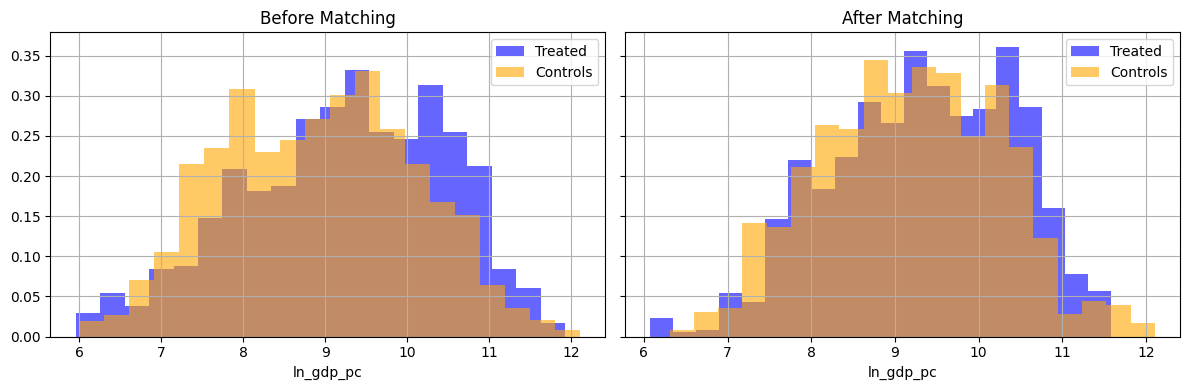

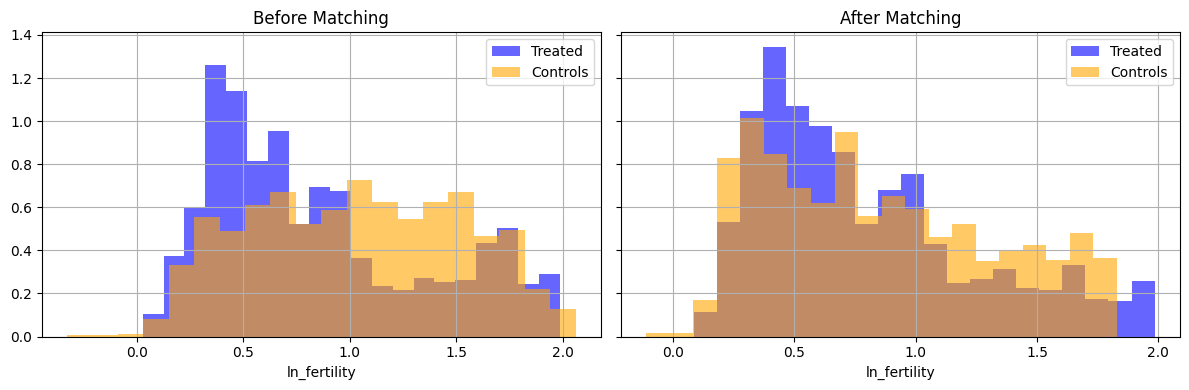

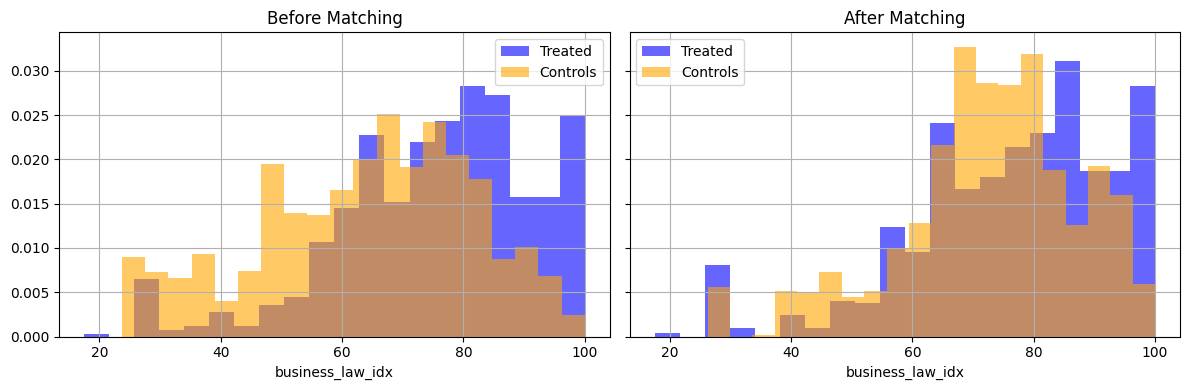

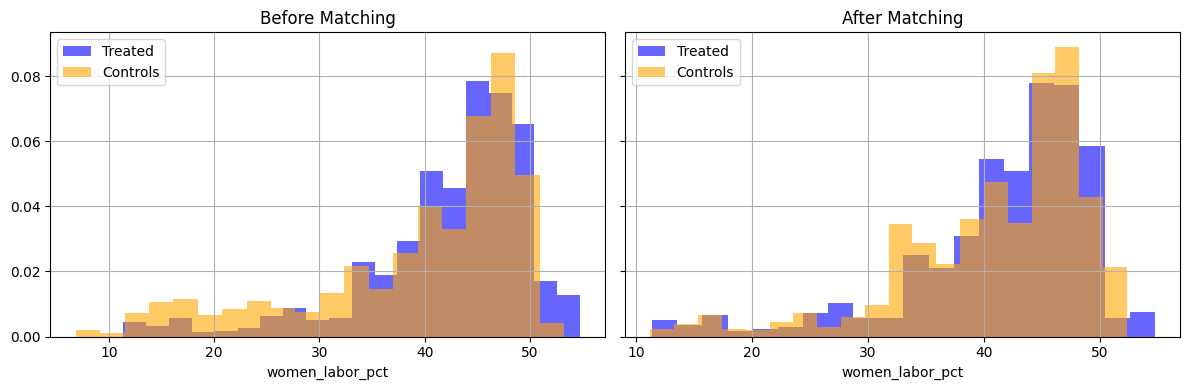

In [32]:
for var in FEATURES:
    if var != "maternal_mortality_pct":  # skip outcome variable
        plot_common_support(df_eligible, var)

In [33]:
all_matched_codes

['ALB',
 'ARE',
 'ARG',
 'ARM',
 'AUS',
 'AUT',
 'BEL',
 'BLR',
 'BOL',
 'CAN',
 'CHE',
 'CHL',
 'CMR',
 'CPV',
 'CRI',
 'DZA',
 'ECU',
 'ESP',
 'ETH',
 'FRA',
 'GBR',
 'GUY',
 'HRV',
 'ITA',
 'LVA',
 'MDA',
 'MEX',
 'MKD',
 'NAM',
 'NIC',
 'NPL',
 'NZL',
 'PER',
 'PRT',
 'SDN',
 'SEN',
 'SLV',
 'SRB',
 'SUR',
 'SVN',
 'TCD',
 'TTO',
 'TUN',
 'UGA',
 'UZB',
 'VNM',
 'ZWE',
 'BGR',
 'QAT',
 'MNG',
 'CHN',
 'USA',
 'JPN',
 'EST',
 'UKR',
 'GHA',
 'IRL',
 'BHS',
 'COL',
 'GIN',
 'PHL',
 'BLZ',
 'PAK',
 'GTM',
 'MUS',
 'ERI',
 'PAN',
 'CYP',
 'PRY',
 'SVK',
 'GRC',
 'LTU',
 'GEO',
 'DOM',
 'BIH',
 'BEN',
 'HND',
 'BGD',
 'URY',
 'FJI',
 'CZE',
 'MRT',
 'DJI',
 'KGZ',
 'ROU',
 'VCT',
 'POL',
 'NGA',
 'HUN',
 'LKA',
 'PNG',
 'TJK',
 'AZE',
 'LBR']

## Parallel trend assumption check with placebo regression

In [34]:
# filter dataset to matched sample
df_matched = df_eligible[df_eligible["country_code"].isin(all_matched_codes)].copy()
print(f"\nMatched panel shape: {df_matched.shape}")
print(f"Countries in matched sample: {df_matched['country_code'].nunique()}")


Matched panel shape: (2538, 13)
Countries in matched sample: 94


In [35]:
def event_col(t):
    if t < 0:
        return f"event_pre{abs(t)}"
    else:
        return f"event_post{t}"

# parallel trend assumption test
def test_parallel_trends(df, treated_col='treated', outcome='maternal_mortality_pct',
                         controls=[], window=5, label=""):
    """
    Placebo regression to test parallel trends assumption.
    Restricts to pre-treatment period and tests whether pre-treatment
    event time dummies are individually and jointly zero.
    
    Parameters
    ----------
    df         : panel dataframe with event_time and treated columns
    treated_col: column indicating treatment status
    outcome    : dependent variable
    controls   : list of control variables
    window     : number of pre-treatment periods to test
    label      : label for print output (e.g. 'before matching', 'after matching')
    """
    d = df.copy()
    d["event_time"] = d["year"] - d["first_cross_year"]
    # create pre-treatment event time dummies
    placebo_dummies = [event_col(t) for t in range(-window, -1)]
    
    for t in range(-window, -1):
        d[event_col(t)] = (
            (d[treated_col]==1) & (d['event_time']==t)
        ).astype(int)

    # restrict to pre-treatment period
    d_pre = (
        d[d["event_time"] < 0]
        .dropna(subset=[outcome] + placebo_dummies + controls)  # drop rows with missing outcome or placebo dummies
        .set_index(["country_code", "year"])
    )

    formula = (
        f"{outcome} ~ "
        + " + ".join(placebo_dummies + controls)
        + " + EntityEffects + TimeEffects"
    )

    model = PanelOLS.from_formula(formula, data=d_pre).fit(cov_type="clustered", cluster_entity=True)

    # joint F-test for all placebo dummies
    restrictions = "=".join(placebo_dummies) + "=0"
    f_test = model.wald_test(formula=restrictions)

    title = f"Parallel Trends Test{' — ' + label if label else ''}"
    print(f"\n── {title} ──")
    print(f"N obs: {model.nobs:,}  |  N countries: {d_pre.index.get_level_values('country_code').nunique()}")
    print(model.summary.tables[1])
    print(f"\nJoint F-test (all pre-trend dummies = 0):")
    print(f"  F-statistic : {f_test.stat:.4f}")
    print(f"  P-value     : {f_test.pval:.4f}")
    if f_test.pval > 0.05:
        print("  ✓ Fail to reject H0 — parallel trends assumption holds")
    else:
        print("  ✗ Reject H0 — parallel trends assumption violated")

    return model, f_test

In [36]:
pta = test_parallel_trends(df_matched, treated_col="treated", outcome="maternal_mortality_pct",
                           controls=[], 
                           window=5, label="after matching")


── Parallel Trends Test — after matching ──
N obs: 2,042  |  N countries: 94
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
event_pre5    -0.0002     0.0079    -0.0295     0.9765     -0.0156      0.0152
event_pre4    -0.0019     0.0090    -0.2125     0.8318     -0.0195      0.0157
event_pre3    -0.0045     0.0102    -0.4388     0.6609     -0.0244      0.0155
event_pre2    -0.0054     0.0115    -0.4744     0.6353     -0.0280      0.0171

Joint F-test (all pre-trend dummies = 0):
  F-statistic : 1.9856
  P-value     : 0.7384
  ✓ Fail to reject H0 — parallel trends assumption holds


## Run FE event study regression

In [37]:
def event_study_fe(df_matched, window=5, controls=["ln_fertility"]):
    # ── assign event time ──────────────────────────────────────────────────────────
    df_matched["event_time"] = df_matched["year"] - df_matched["first_cross_year"]

    # never-treated countries have event_time far outside window
    # assign them to the reference period (t=-1) so they stay in sample
    # as part of the control group without getting a dummy
    df_matched["event_time_capped"] = df_matched["event_time"].clip(-window, window)
    df_matched.loc[df_matched["treated"] == 0, "event_time_capped"] = -1

    # keep only treated countries within the window + all never-treated
    df_event = df_matched[
        (df_matched["treated"] == 0) |
        (df_matched["event_time"].between(-window, window))
    ].copy()

    # ── create event time dummies — omit t=-1 as baseline ─────────────────────────
    for t in range(-window, window + 1):
        # if t == -1:
        #     continue
        df_event[event_col(t)] = (
            (df_event["treated"] == 1) & (df_event["event_time"] == t)
        ).astype(int)

    event_dummies = [event_col(t) for t in range(-window, window + 1) if t != -1]
    formula       = (
        "maternal_mortality_pct ~ "
        + " + ".join(event_dummies + controls)
        + " + EntityEffects + TimeEffects"
    )

    d = (
        df_event
        .dropna(subset=["maternal_mortality_pct"] + event_dummies + controls)
        .set_index(["country_code", "year"])
    )

    model_event = PanelOLS.from_formula(formula, data=d).fit(
        cov_type="clustered", cluster_entity=True, 
    )

    print(f"N obs: {model_event.nobs:,}  |  N countries: {d.index.get_level_values('country_code').nunique()} | Window: {window}")
    print(f"R² (within): {model_event.rsquared:.3f}")
    print(model_event.summary.tables[1])
    # return model_event

### Varying time windows, no controls

In [38]:
for w in [3,4,5]:
    event_study_fe(df_matched, window=w, controls=[])
    print("\n***************************\n")

N obs: 1,590  |  N countries: 94 | Window: 3
R² (within): 0.003
                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
event_pre3      0.0047     0.0051     0.9359     0.3495     -0.0052      0.0146
event_pre2      0.0030     0.0027     1.0766     0.2818     -0.0024      0.0083
event_post0    -0.0067     0.0026    -2.6302     0.0086     -0.0117     -0.0017
event_post1    -0.0089     0.0047    -1.9174     0.0554     -0.0180      0.0002
event_post2    -0.0083     0.0063    -1.3271     0.1847     -0.0206      0.0040
event_post3    -0.0097     0.0076    -1.2851     0.1990     -0.0246      0.0051

***************************

N obs: 1,673  |  N countries: 94 | Window: 4
R² (within): 0.005
                              Parameter Estimates                              
             Parameter  Std. Err.     T-st

### Varying time windows, gdp as control

In [39]:
for w in [3,4,5]:
    event_study_fe(df_matched, window=w, controls=['ln_gdp_pc'])
    print("\n***************************\n")

N obs: 1,562  |  N countries: 94 | Window: 3
R² (within): 0.005
                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
event_pre3      0.0059     0.0050     1.1744     0.2404     -0.0039      0.0157
event_pre2      0.0036     0.0027     1.3198     0.1871     -0.0017      0.0089
event_post0    -0.0073     0.0025    -2.8484     0.0045     -0.0123     -0.0023
event_post1    -0.0099     0.0046    -2.1528     0.0315     -0.0190     -0.0009
event_post2    -0.0097     0.0062    -1.5573     0.1196     -0.0219      0.0025
event_post3    -0.0116     0.0075    -1.5456     0.1224     -0.0263      0.0031
ln_gdp_pc    2.754e-05     0.0241     0.0011     0.9991     -0.0473      0.0473

***************************

N obs: 1,645  |  N countries: 94 | Window: 4
R² (within): 0.009
                              Parameter Es

### Varying time windows, fertility as control

In [40]:
for w in [3,4,5]:
    event_study_fe(df_matched, window=w, controls=['ln_fertility'])
    print("\n***************************\n")

N obs: 1,590  |  N countries: 94 | Window: 3
R² (within): 0.057
                              Parameter Estimates                               
              Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------
event_pre3       0.0053     0.0050     1.0633     0.2878     -0.0045      0.0150
event_pre2       0.0033     0.0027     1.2109     0.2261     -0.0020      0.0085
event_post0     -0.0065     0.0026    -2.4973     0.0126     -0.0116     -0.0014
event_post1     -0.0093     0.0046    -2.0248     0.0431     -0.0184     -0.0003
event_post2     -0.0091     0.0061    -1.4915     0.1360     -0.0212      0.0029
event_post3     -0.0105     0.0073    -1.4425     0.1494     -0.0248      0.0038
ln_fertility     0.0997     0.0416     2.3996     0.0165      0.0182      0.1813

***************************

N obs: 1,673  |  N countries: 94 | Window: 4
R² (within): 0.058
                              Pa

### Varying time windows, all controls

In [41]:
for w in [3,4,5]:
    event_study_fe(df_matched, window=w, controls=[f for f in FEATURES if f!='maternal_mortality_pct'])

N obs: 1,560  |  N countries: 94 | Window: 3
R² (within): 0.057
                                Parameter Estimates                                 
                  Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------------
event_pre3           0.0066     0.0049     1.3636     0.1729     -0.0029      0.0162
event_pre2           0.0041     0.0026     1.5565     0.1198     -0.0011      0.0093
event_post0         -0.0073     0.0027    -2.7443     0.0061     -0.0125     -0.0021
event_post1         -0.0111     0.0047    -2.3655     0.0181     -0.0203     -0.0019
event_post2         -0.0113     0.0061    -1.8392     0.0661     -0.0233      0.0007
event_post3         -0.0140     0.0072    -1.9420     0.0523     -0.0281      0.0001
ln_gdp_pc           -0.0194     0.0369    -0.5257     0.5992     -0.0919      0.0530
ln_fertility         0.0910     0.0476     1.9143     0.0558     -0.0023      0.1843
b

## Run FD event study regression

In [46]:
def event_study_fd(df_matched, window=5, controls=["ln_fertility"]):

    d = df_matched.copy()
    d["event_time"] = d["year"] - d["first_cross_year"]

    # ── first difference the outcome and controls ──────────────────────────────
    d = d.sort_values(["country_code", "year"])
    d["d_maternal_mortality_pct"] = d.groupby("country_code")["maternal_mortality_pct"].diff()
    for c in controls:
        d[f"d_{c}"] = d.groupby("country_code")[c].diff()
    diff_controls = [f"d_{c}" for c in controls]

    # ── keep only treated within window + all never-treated ───────────────────
    df_event = d[
        (d["treated"] == 0) |
        (d["event_time"].between(-window, window))
    ].copy()

    # ── create event time dummies — omit t=-1 as baseline ─────────────────────
    for t in range(-window, window + 1):
        # if t == -1:
        #     continue
        df_event[event_col(t)] = (
            (df_event["treated"] == 1) & (df_event["event_time"] == t)
        ).astype(int)

    event_dummies = [event_col(t) for t in range(-window, window + 1)]

    formula = (
        "d_maternal_mortality_pct ~ "
        + " + ".join(event_dummies + diff_controls)
        + " + TimeEffects"   # no EntityEffects — FD already removes country FE
    )

    d_idx = (
        df_event
        .dropna(subset=["d_maternal_mortality_pct"] + event_dummies + diff_controls)
        .set_index(["country_code", "year"])
    )

    model_event = PanelOLS.from_formula(formula, data=d_idx).fit(
        cov_type="clustered", cluster_entity=True
    )

    print(f"N obs: {model_event.nobs:,}  |  N countries: {d_idx.index.get_level_values('country_code').nunique()} | Window: {window}")
    print(f"R² (within): {model_event.rsquared:.3f}")
    print(model_event.summary.tables[1])

    return model_event

### Varying time window, no control

In [48]:
for w in [3,4,5]:
    event_study_fd(df_matched, window=w, controls=[])
    print("\n***************************\n")

N obs: 1,542  |  N countries: 94 | Window: 3
R² (within): 0.008
                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
event_pre3     -0.0022     0.0025    -0.8868     0.3753     -0.0070      0.0026
event_pre2     -0.0010     0.0023    -0.4600     0.6456     -0.0055      0.0034
event_pre1     -0.0024     0.0025    -0.9541     0.3402     -0.0073      0.0025
event_post0    -0.0062     0.0024    -2.6314     0.0086     -0.0109     -0.0016
event_post1    -0.0022     0.0027    -0.7979     0.4251     -0.0075      0.0032
event_post2     0.0005     0.0022     0.2330     0.8158     -0.0038      0.0048
event_post3    -0.0016     0.0020    -0.7991     0.4244     -0.0056      0.0023

***************************

N obs: 1,625  |  N countries: 94 | Window: 4
R² (within): 0.008
                              Parameter Es

### Varying time window, fertility as control

In [49]:
for w in [3,4,5]:
    event_study_fd(df_matched, window=w, controls=['ln_fertility'])
    print("\n***************************\n")

N obs: 1,542  |  N countries: 94 | Window: 3
R² (within): 0.008
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
event_pre3        -0.0022     0.0024    -0.8961     0.3703     -0.0070      0.0026
event_pre2        -0.0011     0.0023    -0.4656     0.6415     -0.0055      0.0034
event_pre1        -0.0024     0.0025    -0.9631     0.3357     -0.0073      0.0025
event_post0       -0.0062     0.0024    -2.6270     0.0087     -0.0109     -0.0016
event_post1       -0.0022     0.0027    -0.8081     0.4192     -0.0076      0.0032
event_post2        0.0005     0.0022     0.2250     0.8220     -0.0038      0.0048
event_post3       -0.0016     0.0020    -0.8039     0.4216     -0.0056      0.0023
d_ln_fertility     0.0042     0.0126     0.3350     0.7377     -0.0205      0.0289

**********************

### Varying time windows, gdp as control

In [55]:
for w in [3,4,5]:
    event_study_fd(df_matched, window=w, controls=['ln_gdp_pc'])
    print("\n***************************\n")

N obs: 1,514  |  N countries: 94 | Window: 3
R² (within): 0.013
                              Parameter Estimates                              
             Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-------------------------------------------------------------------------------
event_pre3     -0.0027     0.0024    -1.1320     0.2578     -0.0075      0.0020
event_pre2     -0.0015     0.0022    -0.6812     0.4959     -0.0059      0.0029
event_pre1     -0.0028     0.0025    -1.1254     0.2606     -0.0076      0.0021
event_post0    -0.0066     0.0023    -2.8459     0.0045     -0.0112     -0.0021
event_post1    -0.0027     0.0027    -0.9959     0.3195     -0.0080      0.0026
event_post2     0.0001     0.0022     0.0625     0.9501     -0.0042      0.0045
event_post3    -0.0020     0.0020    -1.0141     0.3107     -0.0059      0.0019
d_ln_gdp_pc    -0.0169     0.0146    -1.1615     0.2456     -0.0456      0.0117

***************************

N obs: 1,597  |  N countri

### Varying time windows, all controls

In [50]:
for w in [3,4,5]:
    event_study_fd(df_matched, window=w, controls=[var for var in FEATURES if var != 'maternal_mortality_pct'])
    print("\n***************************\n")

N obs: 1,512  |  N countries: 94 | Window: 3
R² (within): 0.017
                                 Parameter Estimates                                  
                    Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
--------------------------------------------------------------------------------------
event_pre3            -0.0028     0.0024    -1.1469     0.2516     -0.0075      0.0020
event_pre2            -0.0016     0.0022    -0.7126     0.4762     -0.0060      0.0028
event_pre1            -0.0029     0.0025    -1.1693     0.2425     -0.0077      0.0019
event_post0           -0.0065     0.0023    -2.8213     0.0048     -0.0110     -0.0020
event_post1           -0.0027     0.0027    -1.0144     0.3106     -0.0080      0.0026
event_post2         9.598e-05     0.0022     0.0442     0.9647     -0.0042      0.0044
event_post3           -0.0023     0.0020    -1.1543     0.2486     -0.0062      0.0016
d_ln_gdp_pc           -0.0156     0.0152    -1.0286     0.3038    